In [4]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [5]:
iris =load_iris()

In [8]:
X=iris.data
y=iris.target

In [11]:
X.shape

(150, 4)

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

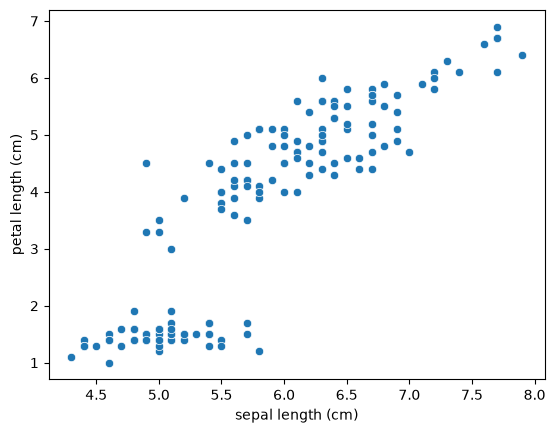

In [20]:
#Visualize
sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,2])

In [22]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler()
X_scaled =scaler.fit_transform(X)

In [34]:
#Optional - Dimensionality Reduction using PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

pca_data=pca.fit_transform(X_scaled)


In [35]:
# elbow method 

wcss =[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

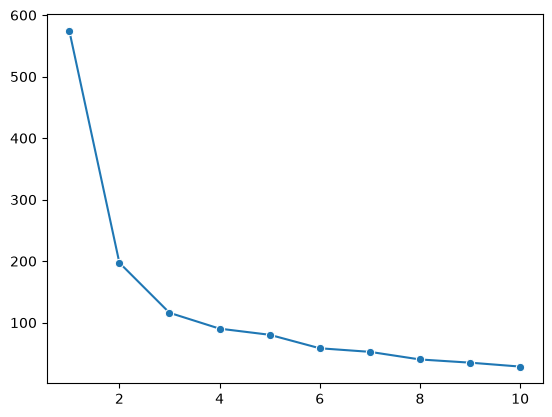

In [36]:
sns.lineplot(x=range(1,11), y=wcss , marker="o")

<Axes: >

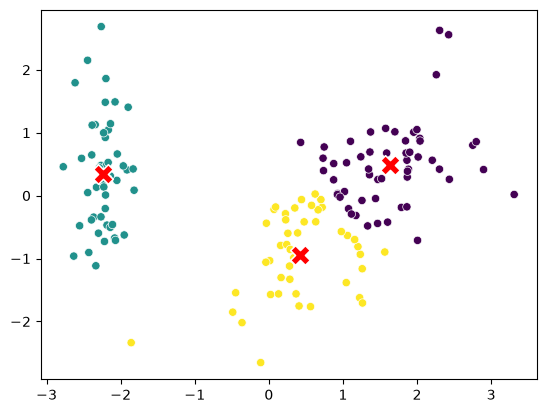

In [45]:
#Kmeans 
kmeans=KMeans(n_clusters=3, random_state=10)
labels=kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker='X', c="red", s=200) #Centroids